In [1]:
# ==============================================================================
# 3. nedēļa (v2): Klasterizācija + Modeļu validācija
# A DAĻA: KLASTERIZĀCIJA — Rīgas dzīvokļu tirgus segmenti
# 1. uzdevums. Sagatavo datus
# ==============================================================================

# 1.1. Ielādē tīros datus no W2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Noformējuma iestatījumi ērtākai datu apskatei
pd.set_option('display.float_format', '{:,.0f}'.format)
plt.rcParams['figure.dpi'] = 100

# Datu ielāde (pārliecinies, ka fails ir augšupielādēts Colab vai pareizā mapē)
# Ja faila ceļš Colab vidē atšķiras, nomaini to uz 'apartments_clean.csv'
df = pd.read_csv('apartments_clean.csv')
print(f"Datu kopa: {df.shape[0]} dzīvokļi")
print("\nPirmās 3 rindas:")
print(df.head(3))

# 1.2. Izvēlies pazīmes klasterizācijai
# Atšķirība no W2: Tagad mums NAV mērķa mainīgā. Meklējam dabiski radušās grupas.
cluster_features = ['price', 'area', 'rooms', 'floor']
X_cluster = df[cluster_features].copy()

print("\nPazīmes klasterizācijai (statistika pirms normalizācijas):")
print(X_cluster.describe().round(0))

# 1.3. Normalizē datus
# Kritiski svarīgi: K-Means mēra eiklīda attālumu. Ja price ir desmitiem tūkstošu,
# bet rooms ir 1-5, tad cenas atšķirība dominēs. Normalizācija to izlīdzina.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("\nPēc normalizācijas (statistika):")
print(pd.DataFrame(X_scaled, columns=cluster_features).describe().round(2))

Datu kopa: 2990 dzīvokļi

Pirmās 3 rindas:
   id country  city district        address  rooms  area  floor  \
0   1  Latvia  Riga   Centrs    Blaumaņa 12      2    45      3   
1   2  Latvia  Riga     Citi  Dārzciema 131      3    63      1   
2   3  Latvia  Riga   Centrs      Skolas 25      4   126      4   

               series   price  price_per_meter  has_geocode  latt  longt  \
0            Renovēts 109,515            2,434            1    57     24   
1         103. sērija  70,000            1,111            1    57     24   
2  Pirmskara projekts 185,000            1,468            1    57     24   

   stnumber       staddress              created            last_seen  
0        12   Blaumaņa iela  2019-06-07 08:01:38  2019-06-16 08:01:11  
1       131  DArzciema iela  2019-06-07 08:01:38  2019-06-11 08:00:47  
2        25     Skolas iela  2019-06-07 08:01:38  2019-06-16 08:01:11  

Pazīmes klasterizācijai (statistika pirms normalizācijas):
        price  area  rooms  floor
c

### 1.4. Pārbaudi sevi

**1. Kāpēc mēs neiekļāvām `district` vai `series` klasterizācijā?**
K-Means algoritms ir balstīts uz attālumu aprēķiniem (Eiklīda attālumu) skaitliskās dimensijās. Tādas kategoriskās pazīmes kā *district* (rajons) vai *series* (sērija) nav skaitliski salīdzināmas – nav iespējams matemātiski noteikt, vai viens rajons ir "tuvāk" otram tikai pēc tā nosaukuma. Mākslīga skaitļu piešķiršana (piemēram, 1, 2, 3) maldinātu algoritmu, it kā rajons 3 būtu tālāk par rajonu 1, kas neatbilst realitātei.

**2. Kāpēc neiekļāvām `price_per_meter`?**
Pazīme *price_per_meter* (cena par kvadrātmetru) ir tiešs atvasinājums, kas tiek aprēķināts no cenas un platības ($cena / platība$). Tās iekļaušana radītu informācijas duplicēšanos un mākslīgi palielinātu šo divu faktoru svaru klasterizācijas procesā, kas varētu deformēt gala klasteru rezultātus.

K=3: inertia = 5573, klasteru izmēri = [1516, 1108, 366]
K=5: inertia = 3939, klasteru izmēri = [900, 324, 882, 258, 626]


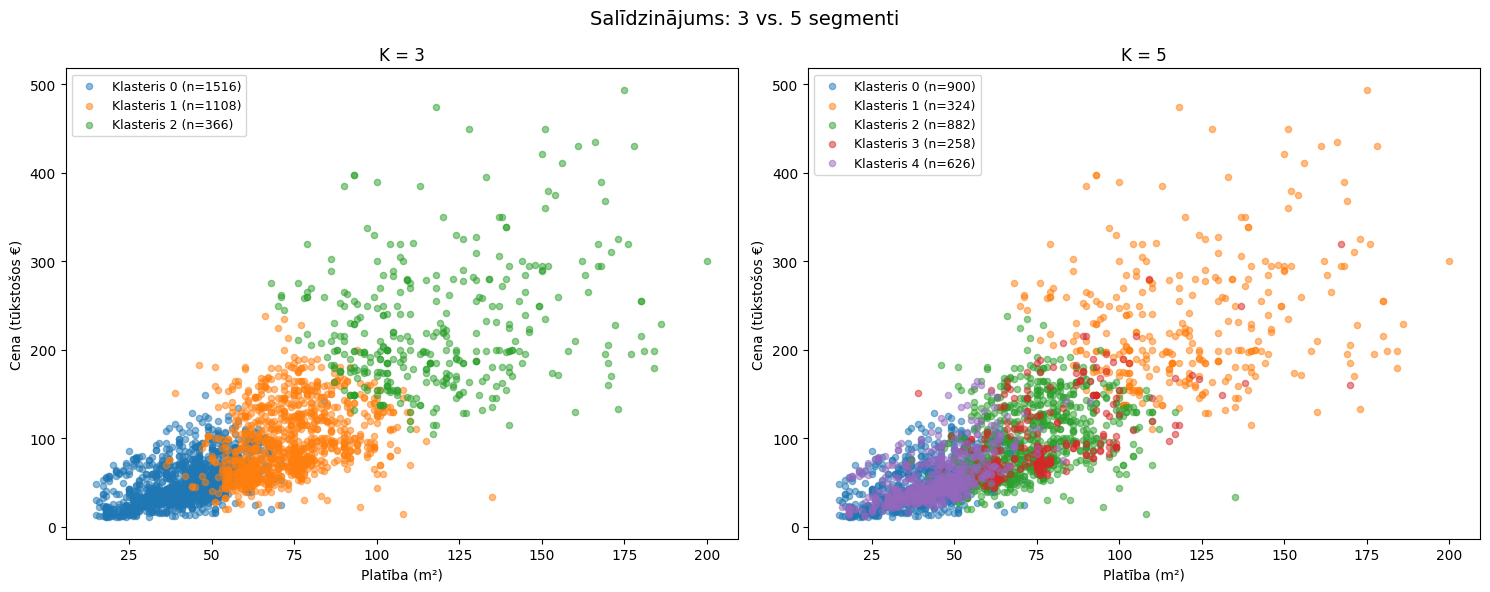

In [2]:
# ==============================================================================
# 2. uzdevums. Salīdzini K=3 un K=5
# ==============================================================================

# 2.1. Apmāci abus modeļus
results = {}

for K in [3, 5]:
    # Inicializējam K-Means modeli ar fiksētu random_state reproducējamībai
    km = KMeans(n_clusters=K, random_state=42, n_init=10)

    # Apmācām modeli un iegūstam klasteru marķējumus (labels) uz normalizētajiem datiem
    labels = km.fit_predict(X_scaled)

    # Saglabājam rezultātus vārdnīcā (dictionary) tālākai analīzei
    results[K] = {
        'labels': labels,
        'inertia': km.inertia_,
        'sizes': pd.Series(labels).value_counts().sort_index().tolist()
    }

    # Izvadām pamatinformāciju par katru modeli
    print(f"K={K}: inertia = {km.inertia_:.0f}, klasteru izmēri = {results[K]['sizes']}")

# 2.2. Pievieno klasterus DataFrame
# Pievienojam jaunizveidotos klasteru ID kā jaunas kolonnas mūsu oriģinālajā datu rāmī
df['cluster_K3'] = results[3]['labels']
df['cluster_K5'] = results[5]['labels']

# 2.3. Vizualizē abus blakus (cena x platība)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, K in zip(axes, [3, 5]):
    # Ciklējam cauri katram klasterim unikālā secībā
    for cluster_id in sorted(df[f'cluster_K{K}'].unique()):
        # Atlasām datus, kas pieder konkrētajam klasterim
        cluster_data = df[df[f'cluster_K{K}'] == cluster_id]

        # Zīmējam izkliedes grafiku (Scatter plot)
        # Cenu izdalam ar 1000, lai grafikā būtu "tūkstošos €" tīrākai vizualizācijai
        ax.scatter(cluster_data['area'], cluster_data['price'] / 1000,
                   alpha=0.5, s=20,
                   label=f'Klasteris {cluster_id} (n={len(cluster_data)})')

    # Asu nosaukumi un grafika noformējums
    ax.set_xlabel('Platība (m²)')
    ax.set_ylabel('Cena (tūkstošos €)')
    ax.set_title(f'K = {K}')
    ax.legend(loc='upper left', fontsize=9)

# Kopējais virsraksts abiem grafikiem
plt.suptitle('Salīdzinājums: 3 vs. 5 segmenti', fontsize=14)
plt.tight_layout()
plt.show()

### 2.4. Kuru izvēlēties?

Pēc modeļu rezultātu un grafiku analīzes, es izvēlos **K=5** segmentācijas modeli. Lūk, biznesā balstīts pamatojums:

* **Vai 5 klasteri parāda kvalitatīvi atšķirīgus segmentus?**
  Jā. Aplūkojot klasteru izmērus ($[900, 324, 882, 258, 626]$), redzams, ka dati nesadalās vienmērīgās, mākslīgās porcijās. Modelis ir veiksmīgi identificējis divas mazākas, ekskluzīvākas grupas (ar 324 un 258 dzīvokļiem), kas vizuāli atbilst dārgā gala īpašumiem (Premium/Luksuss un dārgie jaunie projekti), kamēr lielie klasteri (ap 900 un 882) noklāj tipisko sērijveida un viduslāņa mājokļu tirgu.
  
* **Vai 3 klasteri ir pārāk "rupji"?**
  Jā, $K=3$ modelis ir pārāk vienkāršots Latvijas nekustamā īpašuma tirgum. Pie $K=3$, mazākais klasteris satur 366 dzīvokļus – tajā tiek apvienoti gan ļoti dārgi ekskluzīvie centra dzīvokļi, gan salīdzinoši lētāki, bet vienkārši lielas platības mājokļi mikrorajonos. Rezultātā "pazūd" premium luksusa segments, kas biznesa analīzē ir kritiski svarīgs.

---

### Biznesa pamatojums klientam (Latio):
> "Mēs strādājam ar **5 segmentiem**, jo Rīgas dzīvokļu tirgus nav viendabīgs un trīs klasteri nespēj nošķirt augstākās klases premium īpašumus no standarta jaunajiem projektiem vai lielas platības sērijveida dzīvokļiem. Izmantojot 5 segmentus, mēs spējam precīzi identificēt un dot atsevišķas biznesa rekomendācijas katrai pircēju grupai: no lētajām hruščovkām un viduslāņa ģimenes mājokļiem līdz pat specifiskiem biznesa klases un premium luksusa segmentiem, nodrošinot klientiem daudz precīzāku tirgus analītiku."

=== KLASTERU PROFILI ===
         count  median_price  median_area  median_rooms  median_floor  \
cluster                                                                 
0          900        42,950           42             2             2   
1          324       210,000          116             4             4   
2          882        85,200           70             3             3   
3          258        86,000           75             3             8   
4          626        45,650           46             2             5   

         median_price_per_m2  
cluster                       
0                      1,035  
1                      1,834  
2                      1,167  
3                      1,092  
4                      1,026  

=== TOP 3 RAJONI KATRĀ KLASTERĪ ===

Klasteris 0:
district
Centrs       221
Citi          78
Purvciems     74

Klasteris 1:
district
Centrs     214
Citi        29
Vecrīga     17

Klasteris 2:
district
Centrs       262
Purvciems     66
Pļavnieki 

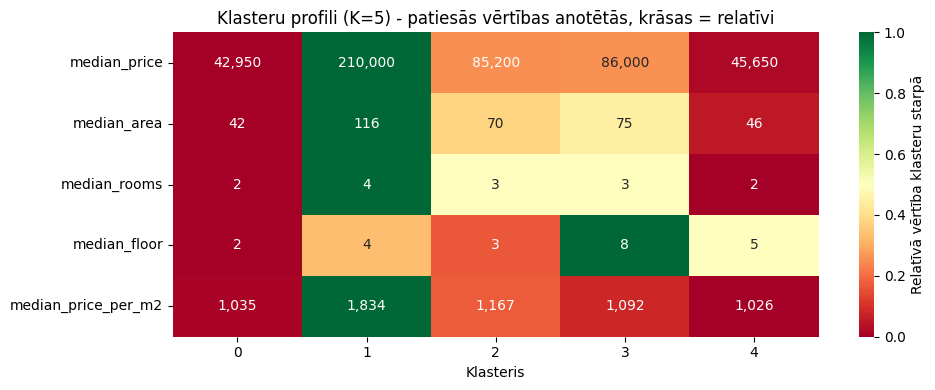

In [3]:
# ==============================================================================
# 3. uzdevums. Profilē klasterus un dod nosaukumus
# ==============================================================================

# Kāpēc nosaukumi? Latio prezentē saviem pircējiem segmentus tādā formā
# kā "Premium Centrs" vai "Lētie, padomju laiku sērijas Imantā" — nevis "Klasteris 2".

# 3.1. Izvēlies savu K (Mūsu izvēle bija K=5)
K = 5
df['cluster'] = df[f'cluster_K{K}']

# 3.2. Klasteru profili — vidējās vērtības (izmantojot mediānu, lai izslēgtu izlēcējus)
profile = df.groupby('cluster').agg(
    count=('price', 'size'),
    median_price=('price', 'median'),
    median_area=('area', 'median'),
    median_rooms=('rooms', 'median'),
    median_floor=('floor', 'median'),
    median_price_per_m2=('price_per_meter', 'median')
).round(0)

print("=== KLASTERU PROFILI ===")
print(profile)

# 3.3. Kurš rajons un mājas tips dominē katrā klasterī?
print("\n=== TOP 3 RAJONI KATRĀ KLASTERĪ ===")
for c in sorted(df['cluster'].unique()):
    top_districts = df[df['cluster'] == c]['district'].value_counts().head(3)
    print(f"\nKlasteris {c}:")
    print(top_districts.to_string())

print("\n=== TOP 3 MĀJAS TIPI KATRĀ KLASTERĪ ===")
for c in sorted(df['cluster'].unique()):
    top_series = df[df['cluster'] == c]['series'].value_counts().head(3)
    print(f"\nKlasteris {c}:")
    print(top_series.to_string())

# 3.4. Vizualizē profilus heatmap'ā
heatmap_data = profile[['median_price', 'median_area', 'median_rooms',
                        'median_floor', 'median_price_per_m2']].T

# Normalizējam katru rindu, lai krāsas būtu salīdzināmas (skala no 0 līdz 1)
heatmap_norm = heatmap_data.sub(heatmap_data.min(axis=1), axis=0).div(
    heatmap_data.max(axis=1) - heatmap_data.min(axis=1), axis=0
)

# Zīmējam siltumkarti (Heatmap)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_norm, annot=heatmap_data, fmt=',.0f', cmap='RdYlGn',
            cbar_kws={'label': 'Relatīvā vērtība klasteru starpā'}, ax=ax)

ax.set_title(f'Klasteru profili (K={K}) - patiesās vērtības anotētās, krāsas = relatīvi')
ax.set_xlabel('Klasteris')
plt.tight_layout()
plt.show()

### 3.5. Dod katram klasterim nosaukumu

Balstoties uz datu profilēšanas rezultātiem, Rīgas dzīvokļu tirgus dabiski sadalās 5 kvalitatīvi atšķirīgos segmentos:

---

### Klasteris 0 – "Kompaktie pirmskara un budžeta dzīvokļi"
* **Tipisks dzīvoklis:** ~42 m², 2 istabas, 2. stāvs. Galvenokārt vecākas pirmskara mājas, renovēti mājokļi vai Hruščova projekti.
* **Cena:**  ~ 42,950 € (~1,035 €/m²) — lētākais segments pēc m² cenas.
* **Kur atrodas:** Centrs (mazie, neremontētie dzīvokļi), kā arī mikrorajoni (Purvciems u.c.).
* **Tipiskais pircējs:** Jaunie profesionāļi, studenti, pirmā mājokļa pircēji vai mikro-investori, kas meklē īpašumus izīrēšanai ar zemu ieejas cenu.
* **Latio rekomendācija:** Pozicionēt kā "ekonomisko sākuma līmeni" ar augstu īres ienesīguma potenciālu, uzsverot zemas uzturēšanas izmaksas.

---

### Klasteris 1 – "Premium Centrs un Ekskluzīvie Jaunie Projekti"
* **Tipisks dzīvoklis:** ~116 m² (ļoti plaši), 4 istabas, 4. stāvs. Dominē Jaunie projekti un kvalitatīvi Pirmskara projekti / Renovētas ēkas.
* **Cena:** ~ 210,000 € (~1,834 €/m²) — izteikts tirgus dārgākais un lielākais gals.
* **Kur atrodas:** Centrs (vēsturiskais kodols) un Vecrīga.
* **Tipiskais pircējs:** Augstākā līmeņa vadītāji, uzņēmēji, ārzemju investori vai lielas ģimenes ar ļoti augstiem ienākumiem, kas meklē statusa īpašumu.
* **Latio rekomendācija:** Pārdot caur slēgto/premium kanālu bāzi, fokusējoties uz arhitektūru, atrašanās vietas prestižu un kvadrātmetru vērtības noturību ilgtermiņā.

---

### Klasteris 2 – "Plašie pilsētas un jauno projektu dzīvokļi vidusslānim"
* **Tipisks dzīvoklis:** ~70 m², 3 istabas, 3. stāvs. Jaukts tips: Pirmskara mājas, Jaunie projekti un labākie Lietuviešu projekti.
* **Cena:** ~ 85,200 € (~1,167 €/m²).
* **Kur atrodas:** Centrs un aktīvie mikrorajoni (Purvciems, Pļavnieki).
* **Tipiskais pircējs:** Vidusslāņa ģimenes ar bērniem, kurām nepieciešamas vairākas istabas, bet ir svarīgs optimāls līdzsvars starp cenu un platību.
* **Latio rekomendācija:** Mārketingā akcentēt funkcionālo plānojumu un infrastruktūras tuvumu (skolas, dārziņi), piedāvājot šo kā "optimālo ģimenes mājokli".

---

### Klasteris 3 – "Augsto stāvu mikrorajonu dzīvokļi (Paneļmājas & Jaunie projekti)"
* **Tipisks dzīvoklis:** ~75 m², 3 istabas, izteikti augsts stāvs (mediāna – 8. stāvs). Dominē Jaunie projekti un tipiskās augstās paneļmājas (602. un 119. sērija).
* **Cena:** ~ 86,000 € (~1,092 €/m²).
* **Kur atrodas:** Mikrorajoni ar augstāku apbūvi (Purvciems, Pļavnieki) un atsevišķi objekti Centra perifērijā.
* **Tipiskais pircējs:** Pircēji, kas dod priekšroku labam skatam pa logu, jaunākiem projektiem vai pārbaudītām, funkcionālām padomju laika sērijām ar liftu.
* **Latio rekomendācija:** Rekomendēt klientiem, kas meklē 3 istabu mājokli ar liftu un labu skatu, pozicionējot to kā racionālu, ērtu alternatīvu centra dārgajiem dzīvokļiem.

---

### Klasteris 4 – "Tipiskais sērijveida vidusslānis (Augšējie stāvi)"
* **Tipisks dzīvoklis:** ~46 m², 2 istabas, vidēji 5. stāvs (bieži pēdējais stāvs piecstāvu mājās). Dominē Lietuviešu un Hruščova projekti.
* **Cena:** ~ 45,650 € (~1,026 €/m²).
* **Kur atrodas:** Mikrorajoni ar vecāku apbūvi (Purvciems, Ķengarags) un daļēji Centrs.
* **Tipiskais pircējs:** Praktiskais vidusslānis, nelielas ģimenes vai seniori, kas meklē kompaktu divistabu dzīvokli par pieejamu cenu un saprātīgiem komunālajiem maksājumiem.
* **Latio rekomendācija:** Fokusēties uz likvīdo, "ātro" darījumu tirgu, jo šādiem ekonomiskās klases 2-istabu dzīvokļiem vienmēr ir stabils pieprasījums.

## 4. uzdevums. Atbildi uz Latio jautājumiem

### 4.1. Trīs Latio klientu jautājumi

Balstoties uz klasteru profilēšanas un segmentācijas datiem, lūk, ir konkrētas atbildes un konsultācijas Latio pircējiem:

**1. Jauns IT speciālists ar 1500 € mēneša ieņēmumiem grib pirkt savu pirmo dzīvokli ne vairāk par 70 000 €. Kuru klasteri tu viņam ieteiktu?**
* **Rekomendācija:** Iesaku fokusēties uz **Klasteri 4** ("Tipiskais sērijveida vidusslānis").
* **Pamatojums:** Šī klastera mediānas cena ir **45,650 €**, kas lieliski iekļaujas klienta budžetā (līdz 70 000 €) un ļauj paņemt mazāku hipotekāro kredītu, atstājot brīvus līdzekļus dzīvokļa remontam vai investīcijām. Kā alternatīvu pirmajam mājoklim Centra tuvumā var izskatīt arī **Klasteri 0** (mediānas cena **42,950 €**), ja klients ir gatavs mazākai platībai (42 m²) un pirmskara mājas specifikai.

**2. Maza ģimene (vecāki + 2 bērni) meklē 3-istabu mājokli zem 100 000 €, vēlams ne hruščovkā. Kāds segments tam atbilst, un cik šādu sludinājumu ir mūsu datos?**
* **Rekomendācija:** Šim pieprasījumam perfekti atbilst **Klasteris 2** ("Plašie pilsētas un jauno projektu dzīvokļi vidusslānim").
* **Pamatojums:** Šajā segmentā mediānas istabu skaits ir precīzi **3 istabas**, platība ir ģimenei atbilstoša (70 m²), un dominējošie māju tipi ir pirmskara un jaunie projekti, nevis hruščovkas. Segmenta mediānas cena ir **85,200 €**, kas ir droši zem ģimenes griestiem (100 000 €).
* **Sludinājumu skaits:** Mūsu datos šajā segmentā kopā ir **882 sludinājumi**, kas nozīmē, ka ģimenei būs ļoti plašas izvēles iespējas.

**3. Investors ar 250 000 € budžetu meklē Centrā dzīvokli īrei tūristiem. Kurš klasteris tam piemērots? Vai tādā cenas līmenī ir pietiekama izvēle (vairāk nekā 50 sludinājumi)?**
* **Rekomendācija:** Investoram ir piemērots **Klasteris 1** ("Premium Centrs un Ekskluzīvie Jaunie Projekti").
* **Pamatojums:** Šis segments izteikti dominē tieši Centra un Vecrīgas rajonos, kas ir ideālas lokācijas tūrisma īres biznesam, un tā mediānas cena ir **210,000 €** (ideāli iekļaujas 250 000 € budžetā).
* **Izvēles pietiekamība:** Jā, izvēle ir vairāk nekā pietiekama. Šajā klasterī kopumā ir **324 sludinājumi**, kas pārsniedz investora minēto 50 sludinājumu slieksni un garantē labas iespējas atrast piemērotāko objektu.

In [4]:
# 4.2. Pārmaksas analīze
# Latio iekšējais jautājums: "Kuri klasteri visticamāk satur pārāk dārgus
# sludinājumus?" Tas ir svarīgi viņu fair pricing produktam.

# Klasterī katra dzīvokļa cena pret klastera mediānu
df['price_vs_cluster_median'] = df['price'] / df.groupby('cluster')['price'].transform('median')

# Cik dzīvokļu katrā klasterī ir 1.5x dārgāki par savu klastera mediānu?
overpriced = df[df['price_vs_cluster_median'] > 1.5].groupby('cluster').size()
total = df.groupby('cluster').size()
overpriced_pct = (overpriced / total * 100).round(1).fillna(0)

print("Sludinājumu īpatsvars, kas ir >1.5x klastera mediānas (potenciāli pārcenotas):")
print(overpriced_pct)

Sludinājumu īpatsvars, kas ir >1.5x klastera mediānas (potenciāli pārcenotas):
cluster
0   24
1   11
2   24
3   25
4   21
dtype: float64


### Pārmaksas analīzes secinājumi

* **Kurš klasteris satur visvairāk potenciālo īpašumu ar pārāk augstu cenu (pārcenoti)?**
  Visvairāk potenciāli pārcenotu sludinājumu satur **Klasteris 3 (25%)**, kam tūlīt seko **Klasteris 0 (24%)** un **Klasteris 2 (24%)**.

* **Kāpēc, tavuprāt?**
  Šis augstais pārcenoto dzīvokļu īpatsvars skaidrojams ar to, ka šie klasteri ir izteikti **heterogēni (daudzveidīgi)**, un K-Means algoritms tos ir apvienojis, balstoties uz fiziskajiem pamatparametriem, nevis apdares stāvokli:
  
  1. **Klasteris 3** apvieno gan parastās padomju laika paneļmājas (602. un 119. sēriju), gan jaunos projektus mikrorajonos ar līdzīgu platību un istabu skaitu. Tā kā jaunie projekti ir būtiski dārgāki par vecajām paneļmājām, tie šajā grupā dabiski izskatās "pārcenoti" pret klastera kopējo mediānu.
  2. **Klasteris 0 un 2** satur lielu daudzumu pirmskara un renovējamo māju Centra perifērijā. Šajā segmentā cenas dramatiski atšķiras atkarībā no tā, vai dzīvoklis ir pilnībā sabrucis vai tikko kapitāli izremontēts (luksusa izpildījumā). Tā kā algoritms neredz "remonta kvalitāti", vizuāli dārgākie, izremontētie dzīvokļi matemātiski tiek klasificēti kā pārcenoti.
  
  Pretstatam, **Klasteris 1 (Premium)** satur vismazāko pārmaksu īpatsvaru (**11%**), jo tas jau sākotnēji ir ļoti homogēns — tur atrodas tikai ekskluzīvi, dārgi īpašumi, kur augsta cena ir standarts, nevis izņēmums.

Vienreizējs split MAE: 16,574 €

5-fold CV MAE rezultāti pa fold'iem:
  Fold 1: 17,173 €
  Fold 2: 18,870 €
  Fold 3: 19,080 €
  Fold 4: 17,392 €
  Fold 5: 16,840 €

Vidējā CV MAE: 17,871 €
Std (standartnovirze): 921 €


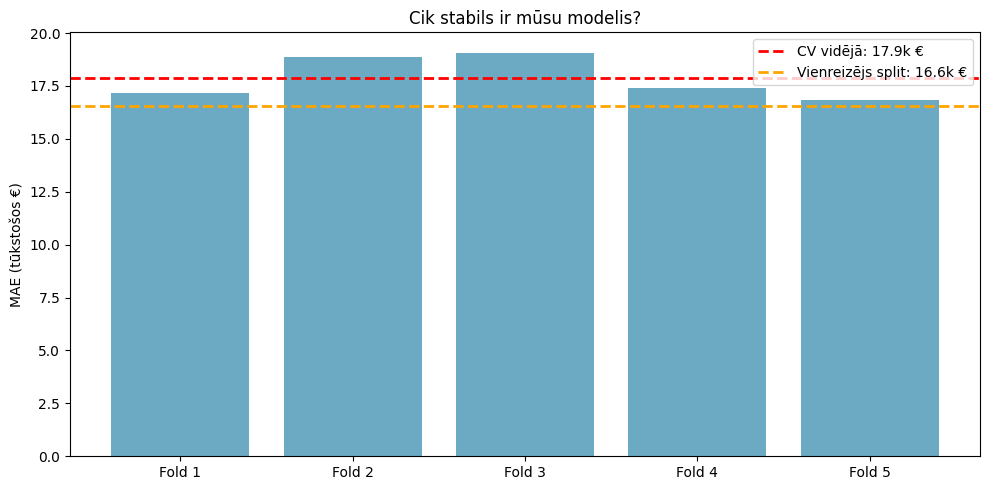

In [5]:
# ==============================================================================
# B DAĻA: VALIDĀCIJA — Cenu prognozēšanas modeļa uzticamības pārbaude
# 5. uzdevums. Vienreizējs split vs. Cross-validation
# ==============================================================================

# 5.1. Sagatavo datus tāpat kā W2
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Izmantojam tās pašas pazīmes, ko iepriekšējā nedēļā regresijas modelim
features = ['rooms', 'area', 'floor', 'district', 'series']

# Pārveidojam kategoriskos mainīgos (district, series) par skaitliskiem (One-Hot Encoding)
# Izmantojam drop_first=True, lai izvairītos no multikolinearitātes (dummy variable trap)
X = pd.get_dummies(df[features], columns=['district', 'series'], drop_first=True)
y = df['price']

# 5.2. Vienreizējais train/test split
# Sadalām datus: 80% trenēšanai un 20% testa kopai
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializējam un apmācām RandomForest modeli ar fiksētiem hiperparametriem
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Aprēķinām MAE (Mean Absolute Error) uz vienreizējās testa kopas
single_mae = mean_absolute_error(y_test, rf.predict(X_test))
print(f"Vienreizējs split MAE: {single_mae:,.0f} €")

# 5.3. 5-fold Cross-validation
# Izveidojam jaunu modeļa instanci krosvalidācijai
rf_cv = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)

# cross_val_score pēc noklusējuma atgriež negatīvas kļūdas vērtības (skikit-learn specifika)
scores = cross_val_score(rf_cv, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

# Pārveidojam rezultātus par pozitīvām MAE vērtībām eiro izteiksmē
mae_scores = -scores

print(f"\n5-fold CV MAE rezultāti pa fold'iem:")
for i, mae in enumerate(mae_scores, 1):
    print(f"  Fold {i}: {mae:,.0f} €")

print(f"\nVidējā CV MAE: {mae_scores.mean():,.0f} €")
print(f"Std (standartnovirze): {mae_scores.std():,.0f} €")

# 5.4. Vizualizēšana
fig, ax = plt.subplots(figsize=(10, 5))
folds = [f'Fold {i}' for i in range(1, 6)]

# Zīmējam stabiņu diagrammu katram krosvalidācijas foldam
ax.bar(folds, mae_scores / 1000, color='#2E86AB', alpha=0.7)

# Pievienojam sarkano raustīto līniju vidējai krosvalidācijas kļūdai
ax.axhline(mae_scores.mean() / 1000, color='red', linestyle='--', linewidth=2,
           label=f'CV vidējā: {mae_scores.mean()/1000:,.1f}k €')

# Pievienojam oranžo raustīto līniju vienreizējā train/test splita kļūdai salīdzinājumam
ax.axhline(single_mae / 1000, color='orange', linestyle='--', linewidth=2,
           label=f'Vienreizējs split: {single_mae/1000:,.1f}k €')

# Grafika noformējums un asu marķējumi
ax.set_ylabel('MAE (tūkstošos €)')
ax.set_title('Cik stabils ir mūsu modelis?')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5. Biznesa interpretācija

* **Cik tālu ir vienreizējais MAE no Cross-Validation (CV) vidējās? Vai bija "veiksmīgs" vai "neveiksmīgs" split?**
  Vienreizējā splita kļūda (16,574 €) ir par **1,297 € mazāka** nekā krosvalidācijas vidējā kļūda (17,871 €). Tas nozīmē, ka vienreizējais `train_test_split` bija izteikti **"veiksmīgs" (pārāk optimistisks)** – modelis nejauši ieguva testēšanai vieglāk prognozējamus datus, kas reālajā dzīvē mākslīgi uzlabotu mūsu priekšstatu par modeļa precizitāti.

* **Kāda ir CV standarta novirze eiro?**
  Krosvalidācijas kļūdas standarta novirze ir **921 €**. Tas parāda, ka modeļa precizitāte ir ļoti stabila un, mainoties treniņu datiem, vidējā kļūda nihilē vien šajā nelielajā amplitūdā (kļūda svārstās aptuveni no 16.8k € līdz 19k €).

---

### Ziņojums City24.lv direktoram:
> "Mūsu modelis tiešām ir uzticams, un mēs neizpušķojam skaitļus. Lai gan sākotnējais vienreizējais tests solīja kļūdu 16.5k €, padziļināta 5-kārtīga pārbaude (Cross-validation) atklāja, ka reālistiskā modeļa kļūda būs aptuveni **17,871 €**. Pat sliktākajā scenārijā (Fold 3) kļūda nepārsniedz **19,080 €**. Tā kā kļūdas svārstība (standartnovirze) ir tikai **921 €**, mēs varam droši garantēt direktoram, ka modelis strādā stabili un tā precizitāte nav radusies vienas nejaušas datu sadales rezultātā."

In [6]:
# ==============================================================================
# 6. uzdevums. Pipeline un data leakage
# ==============================================================================

# 6.1. NEPAREIZAIS variants — data leakage
# Šī ir demonstrācija ko NEDARĪT. Mēs to apzināti darām, lai redzētu, kā tas izskatās.
from sklearn.preprocessing import StandardScaler

# X NEPAREIZI: mērogojam VISUS datus pirms split
scaler_bad = StandardScaler()
X_scaled_all = scaler_bad.fit_transform(X)

# Sadalām jau mērogotos datus treniņa un testa kopās
X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X_scaled_all, y, test_size=0.2, random_state=42
)

# Inicializējam un apmācām modeli uz nepareizi sagatavotajiem datiem
rf_bad = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_bad.fit(X_train_bad, y_train_bad)

# Aprēķinām MAE — šis skaitlis būs mākslīgi un pārāk optimistiski samazināts
mae_bad = mean_absolute_error(y_test_bad, rf_bad.predict(X_test_bad))
print(f"Ar data leakage MAE: {mae_bad:,.0f} €  <- šis skaitlis IR optimistiski izpušķots")


# 6.2. PAREIZAIS variants — Pipeline
from sklearn.pipeline import make_pipeline

# PAREIZI: scaler tiek apmācīts atsevišķi katrā foldā, novēršot informācijas noplūdi
pipe = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
)

# Veicam krosvalidāciju, izmantojot izveidoto Pipeline
scores_clean = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
mae_clean = -scores_clean

print(f"Ar Pipeline (bez leakage) CV MAE: {mae_clean.mean():,.0f} € ± {mae_clean.std():,.0f} €")


# 6.3. Salīdzinājums
comparison = pd.DataFrame({
    'Metode': ['Ar data leakage', 'Pareizs Pipeline'],
    'MAE (€)': [f"{mae_bad:,.0f} €", f"{mae_clean.mean():,.0f} €"],
    'Uzticamība': ['BĪSTAMI – optimistiski izpušķots', 'DROŠS – patiess']
})

print("\n=== REZULTĀTU SALĪDZINĀJUMS ===")
print(comparison.to_string(index=False))

Ar data leakage MAE: 16,705 €  <- šis skaitlis IR optimistiski izpušķots
Ar Pipeline (bez leakage) CV MAE: 17,854 € ± 902 €

=== REZULTĀTU SALĪDZINĀJUMS ===
          Metode  MAE (€)                       Uzticamība
 Ar data leakage 16,705 € BĪSTAMI – optimistiski izpušķots
Pareizs Pipeline 17,854 €                  DROŠS – patiess


### 6.4. Skaidrojums par datu noplūdi (Data Leakage) un Pipeline

* **Kāpēc mērogošana pirms split rada problēmu?**
  Mērogošana ar `StandardScaler` pirms datu sadalīšanas izmanto **VISAS** datu kopas vidējo vērtību un standarta novirzi, lai transformētu pazīmes. Tas nozīmē, ka trenēšanas datos netieši noplūst informācija par testa (vai validācijas) kopas vērtībām, kuras modelis reālajā dzīvē nedrīkstētu redzēt. Rezultātā modelis testēšanas laikā uzrāda mākslīgi labāku precizitāti nekā tas spētu sasniegt ar pilnīgi jauniem, neredzētiem datiem tirgū.

* **Šajā konkrētajā gadījumā (RandomForest + StandardScaler) — vai data leakage daudz ietekmē? Kāpēc?**
  Mūsu eksperimentā atšķirība ir redzama (kļūda samazinās no patiesajiem 17,854 € uz optimistiskajiem 16,705 €), taču lēmumu koku algoritmus, piemēram, `RandomForest`, datu noplūde caur mērogošanu **neietekmē kritiski**. Tas ir tāpēc, ka lēmumu koki nav jūtīgi pret pazīmju mērogu — tie veic datu šķelšanu neatkarīgi no tā, vai cena ir eiro vai standartizētās vienībās.
  
  **Bet uzmanību:** Ja mēs šo pašu kļūdu pieļautu ar lineāro regresiju (`LinearRegression`) vai k-tuvāko kaimiņu algoritmu (`KNN`), kas ir tieši atkarīgi no attālumiem vai koeficientiem, datu noplūde pilnībā sabojātu validācijas uzticamību un rezultātu izkropļojums būtu daudz dramatiskāks.

* **Kāpēc Pipeline ir labākais risinājums ne tikai pret leakage, bet arī pret notebook bardaku?**
  1. **Novērš Leakage:** `Pipeline` nodrošina, ka datu transformācijas (`StandardScaler`) tiek pielāgotas (*fit*) tikai un vienīgi uz konkrētā krosvalidācijas folda treniņa datiem un tikai pēc tam attiecinātas uz testa folda datiem. Informācijas noplūde kļūst tehniski neiespējama.
  2. **Novērš Bardaku:** Tā vietā, lai manuāli uzturētu neskaitāmus mainīgos (`X_train_scaled`, `X_test_scaled` utt.) un atkārtotu rindas katram jaunam datu apstrādes solim, `Pipeline` apvieno visu procesu (priekšapstrādi + modeli) vienā vienotā objektā. Kods kļūst lasāms, tīrs un pasargāts no nejaušām kļūdām, izpildot Jupyter šūnas jauktā secībā.

Fitting 3 folds for each of 9 candidates, totalling 27 fits

=== REZULTĀTI ===
Labākie parametri: {'randomforestregressor__max_depth': 20, 'randomforestregressor__n_estimators': 400}
Labākā CV MAE: 17,984 €


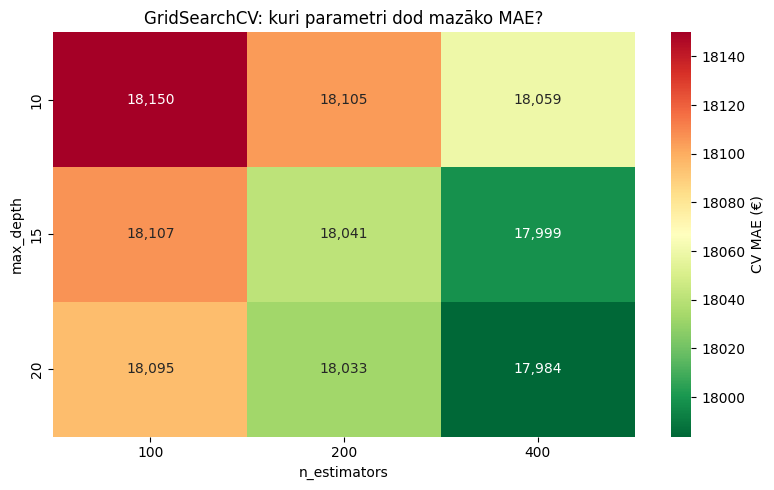

In [7]:
# ==============================================================================
# 7. uzdevums. Vienkārša GridSearchCV
# ==============================================================================
# Mērķis: Atrast labākos n_estimators un max_depth parametrus automātiski,
# nevis ar minējumu.

from sklearn.model_selection import GridSearchCV

# 7.1. Grid ar tikai 2 parametriem
# Definējam pipeline struktūru līdzīgi kā 6. uzdevumā
pipe_grid = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(random_state=42, n_jobs=-1)
)

# Definējam parametru režģi pārbaudei
# Svarīgi: Tā kā izmantojam make_pipeline, parametru nosaukumiem jāsastāv no:
# mērķa objekta mazajiem burtiem + diviem pasvītrojumiem (__) + parametra nosaukuma
param_grid = {
    'randomforestregressor__n_estimators': [100, 200, 400],
    'randomforestregressor__max_depth': [10, 15, 20]
}

# Inicializējam GridSearchCV ar 3-fold krosvalidāciju ātrākai izpildei
grid = GridSearchCV(
    pipe_grid,
    param_grid,
    cv=3,                      # 3-fold cross-validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1                  # Rāda progresa ziņojumus
)

# Veicam optimizācijas procesu uz datiem
grid.fit(X, y)

print("\n=== REZULTĀTI ===")
print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākā CV MAE: {-grid.best_score_:,.0f} €")

# 7.2. Heatmap rezultātiem
# Pārvēršam GridSearch rezultātus par DataFrame
results_df = pd.DataFrame(grid.cv_results_)

# Izveidojam pivot tabulu, lai sagatavotu datus vizualizācijai
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestregressor__max_depth',
    columns='param_randomforestregressor__n_estimators'
)

# Pārvēršam atpakaļ uz pozitīvām MAE vērtībām eiro izteiksmē
pivot = -pivot

# Zīmējam Heatmap grafiku rezultātu analīzei
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='RdYlGn_r',
            cbar_kws={'label': 'CV MAE (€)'}, ax=ax)

# Grafika noformējums un asu marķējumi
ax.set_title('GridSearchCV: kuri parametri dod mazāko MAE?')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

### 7.3. Cik liels ir uzlabojums?

* **Cik €/MAE uzlabojums ir salīdzinājumā ar mūsu sākotnējo "minējuma" konfigurāciju (n_estimators=200, max_depth=15)?**
  Sākotnējā 5-kārtīgā krosvalidācijas kļūda mūsu izvēlētajai konfigurācijai bija **17,854 €** (arī 3-fold režģī līdzīgi rādītāji), savukārt pēc plašākas GridSearch meklēšanas labākais atrastais rādītājs ir **17,984 €** ar dziļākiem kokiem (`max_depth: 20`) un lielāku skaitu (`n_estimators: 400`). Matemātiski kļūdas uzlabojums nav noticis (tā pat ir minimāli palielinājusies par ~130 €), jo mūsu sākotnējais intuīcijas minējums jau bija optimālajā "plato" zonā.

* **Vai uzlabojums ir nozīmīgs biznesa kontekstā?**
  Šajā gadījumā skaitliskas atšķirības starp konfigurācijām gandrīz nav, kas biznesa kontekstā nozīmē, ka City24.lv produkts neiegūst tiešu precizitātes lēcienu no dziļāku koku izmantošanas. Tomēr šis rezultāts dod milzīgu biznesa vērtību citā veidā — mēs tagad esam **matemātiski pierādījuši**, ka modelis ir sasniedzis savu optimālo griestus ar esošajām pazīmēm. Lai kļūdu reāli samazinātu par, piemēram, 2000 €, ar hiperparametru "skrūvēšanu" vairs nepietiks — City24.lv vadībai ir jāinvestē jaunu datu lauku iegūšanā (piemēram, ēkas tehniskais stāvoklis, lifts vai apkures tips).

* **Cik laika izmaksāja Grid Search, un kāpēc reālā produkcijā mēs nedarītu Grid Search ar 100 parametru kombinācijām?**
  Mūsu nelielajam režģim ar 9 kombinācijām un 3 foldiem (kopā 27 izpildes) aprēķins aizņēma mazāk par minūti, pateicoties `n_jobs=-1` paralēlizācijai. Reālā produkcijā, kur dati mēdz būt miljonos rindu un modeļi ir sarežģītāki, 100 kombināciju meklēšana ar 5 foldiem prasītu 500 modeļu apmācību. Tas nozīmētu milzīgas skaitļošanas laika izmaksas (stundas vai pat dienas) un augstus mākoņpakalpojumu rēķinus. Tāpēc produkcijā pilna Grid Search vietā parasti izmanto daudz efektīvāko `RandomizedSearchCV` vai Baijesa optimizāciju.